In [1]:
from backend.utils.gmsh_function import *
from backend.utils.file_path import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from nice_cube_gmsh import *

from backend.efield.efield1 import calculate_electric_magnetic_field_at_point
from backend.efield.efield2 import radiation_intensity_distribution_over_sphere_surface
from backend.efield.efield3 import antenna_directivity_pattern

## This code create a 3D version of the nice Cubesat

In [2]:
name = "Nice_Cube"
path = setup_save_file_paths(name)

In [3]:
# Coding the Nice CubeSat geometry
cm = 1e-2 # 1 cm
C = 10 * cm

mm = 1e-3 # 1 mm

initial_mesh_size = 2 * cm

space_btw_cubesat_and_solar_panel = 0.4 * cm

length_of_connection_between_cubesat_and_solar_panel = 1.5 * cm

gmsh.initialize()

gmsh.model.add("CubeSat")

setup_performance_config()

create_nice_cube_geometry(C, space_btw_cubesat_and_solar_panel, length_of_connection_between_cubesat_and_solar_panel)

generate_and_save_mesh(path.geo, path.msh, initial_mesh_size)

# gmsh.fltk.run()

gmsh.finalize()

[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/Nice_Cube.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/Nice_Cube.msh successfully


In [4]:
feed_point = np.array([
    [C/2 + space_btw_cubesat_and_solar_panel, C/2 - length_of_connection_between_cubesat_and_solar_panel/2, 0],
    [-C/2 + length_of_connection_between_cubesat_and_solar_panel/2, C/2 + space_btw_cubesat_and_solar_panel, 0],
    [-C/2 - space_btw_cubesat_and_solar_panel, -C/2 + length_of_connection_between_cubesat_and_solar_panel/2, 0],
    [C/2 - length_of_connection_between_cubesat_and_solar_panel/2, -C/2 - space_btw_cubesat_and_solar_panel, 0]])

# phase for the 4 feed points of the nice cube, we set the phase to 0, 90, 180, and 270 degrees for the 4 feed points respectively
phase = np.array([0, 90, 180, 270]) * np.pi / 180

# voltage amplitude for the 4 feed points of the nice cube, we set the amplitude to 1 for certain feed points and -1 for others to create a specific radiation pattern
voltage_amplitude = [1, 1, -1, -1]

# Exitation units vector for the 4 feed points of the nice cube depending on how the solar panels are oriented
excitation_units_vector = ['x', 'y', 'x', 'y']

light_speed = 3e8
frequency = 440e6

wavelength = light_speed / frequency
print(f"wavelength = {wavelength} Meter")

wavelength = 0.6818181818181818 Meter


In [5]:
extract_msh_to_mat(path.msh, path.mat)

In [6]:
matrice_z, voltage, current, surface_current_density = radiation_algorithm(path.mat, frequency, feed_point, 
                                                                           voltage_amplitude=voltage_amplitude, 
                                                                           excitation_unit_vector=excitation_units_vector, 
                                                                           gap_width=1.1*initial_mesh_size,
                                                                           voltage_phase=phase)

Calculated Gap Current: 0.0000e+00 A | 0.0000e+00 mA
Calculated Input Impedance at the feed point: inf Ohms
Calculated Active Power delivered to the antenna: 0.0000e+00 W
Maximum Surface Current Density : 0.7132321720383863 (A/m)


In [9]:
observationPoint = np.array([100, 0, 0])

calculate_electric_magnetic_field_at_point(path.mat_mesh2, path.mat_current, observationPoint, mode='radiation')


Frequency = 440000000.0 Hz
Wavelength lambda = 0.6812553499559301 m
The observation point is : [100   0   0]

e_field_total of Nice_Cube at the observation point [100   0   0] is :
-0.0000152 + 0.0000071i V/m
 0.0063646 + 0.0034975i V/m
 0.0001866 + 0.0000089i V/m

h_field_total of Nice_Cube at the observation point [100   0   0] is :
 0.0000000 + 0.0000000i A/m
-0.0000005 + 0.0000000i A/m
 0.0000169 + 0.0000093i A/m

Poynting vector is equal to : 
 0.000000 W/m^2
 0.000000 W/m^2
-0.000000 W/m^2

w = 7.003339481366816e-08 W/m^2

u = 0.0007003339481366816 W/unit solid angle


In [7]:
print("Calculating radiation intensity distribution over sphere surface...")
radiation_intensity_distribution_over_sphere_surface(path.mat_mesh2, path.mat_current, mode='radiation')

Calculating radiation intensity distribution over sphere surface...
MODE SELECTED: radiation
Frequency = 440000000.0 Hz
Wavelength lambda = 0.6812553499559301 m

Total Power :  0.011177
Gain Linear :  3.447945
Gain Logarithmic (Max) :  5.375603 dBi

gap_current = 0.0
Radiation Resistance :  0.000000 Ohms
Input Power (P_in) : 0.0000 W
Data saved successfully to data/antennas_gain_power/Nice_Cube_gain_power.mat


Generating antenna directivity pattern...
Data loaded from data/antennas_gain_power/Nice_Cube_gain_power.mat


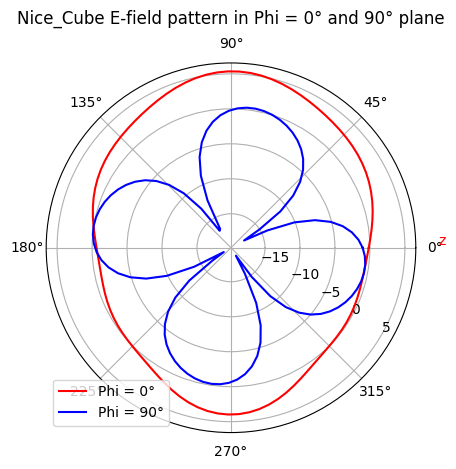

In [8]:
# Step 3: Generating the directivity pattern
print("Generating antenna directivity pattern...")
antenna_directivity_pattern(path.mat_mesh2, path.mat_current, path.mat_gain_power, mode='radiation')